<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/Mutation_Profiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 - Driver Mutation Profiling

**Objective:** Identify and visualize major cancer driver mutations (BRAF, KRAS, NRAS, TP53, EGFR, PIK3CA, PTEN, APC, SMAD4, ALK) from MAF files.

**Outputs:** `driver_mutations.csv`, `oncoplot.png`

In [ ]:
!pip install -q pandas matplotlib seaborn maftools-py 2>/dev/null || echo "Proceeding with pandas/matplotlib only"
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os

DRIVER_GENES = ["BRAF","KRAS","NRAS","TP53","EGFR","PIK3CA","PTEN","APC","SMAD4","ALK"]
print("Driver gene panel:", DRIVER_GENES)


Proceeding with pandas/matplotlib only
Driver gene panel: ['BRAF', 'KRAS', 'NRAS', 'TP53', 'EGFR', 'PIK3CA', 'PTEN', 'APC', 'SMAD4', 'ALK']


## 2.1 Load MAF Files
MAF files are tab-separated with a header block starting with `#`. Update `MAF_DIR` if you downloaded files to a different location in Notebook 1.

In [ ]:
MAF_DIR = "data/maf"

maf_files = glob.glob(os.path.join(MAF_DIR, "*.maf")) + glob.glob(os.path.join(MAF_DIR, "*.maf.gz"))
print(f"Found {len(maf_files)} MAF files")

maf_frames = []
usecols = ["Hugo_Symbol","Chromosome","Start_Position","End_Position",
           "Variant_Classification","Variant_Type","Reference_Allele",
           "Tumor_Seq_Allele2","Tumor_Sample_Barcode","HGVSp_Short"]

for f in maf_files:
    try:
        df = pd.read_csv(f, sep="\t", comment="#", low_memory=False)
        cols_present = [c for c in usecols if c in df.columns]
        maf_frames.append(df[cols_present])
    except Exception as e:
        print(f"Skipping {f}: {e}")

maf_all = pd.concat(maf_frames, ignore_index=True) if maf_frames else pd.DataFrame(columns=usecols)
print(maf_all.shape)
maf_all.head()


Found 0 MAF files
(0, 10)


,Hugo_Symbol,Chromosome,Start_Position,End_Position,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele2,Tumor_Sample_Barcode,HGVSp_Short


## 2.2 Filter to Driver Gene Panel

In [ ]:
driver_muts = maf_all[maf_all["Hugo_Symbol"].isin(DRIVER_GENES)].copy()
print(f"Driver mutation records: {len(driver_muts)}")
driver_muts.head()


Driver mutation records: 0


,Hugo_Symbol,Chromosome,Start_Position,End_Position,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele2,Tumor_Sample_Barcode,HGVSp_Short


## 2.3 Mutation Frequency & Type Summary

In [ ]:
mutation_frequency = (
    driver_muts.groupby("Hugo_Symbol")["Tumor_Sample_Barcode"]
    .nunique()
    .reset_index(name="sample_count")
    .sort_values("sample_count", ascending=False)
)

mutation_type = (
    driver_muts.groupby(["Hugo_Symbol","Variant_Classification"])
    .size()
    .reset_index(name="mutation_type_count")
)

driver_mutations = driver_muts.merge(mutation_frequency, on="Hugo_Symbol", how="left")
driver_mutations.to_csv("driver_mutations.csv", index=False)

mutation_frequency


,Hugo_Symbol,sample_count


## 2.4 Oncoplot-style Mutation Frequency Bar Chart

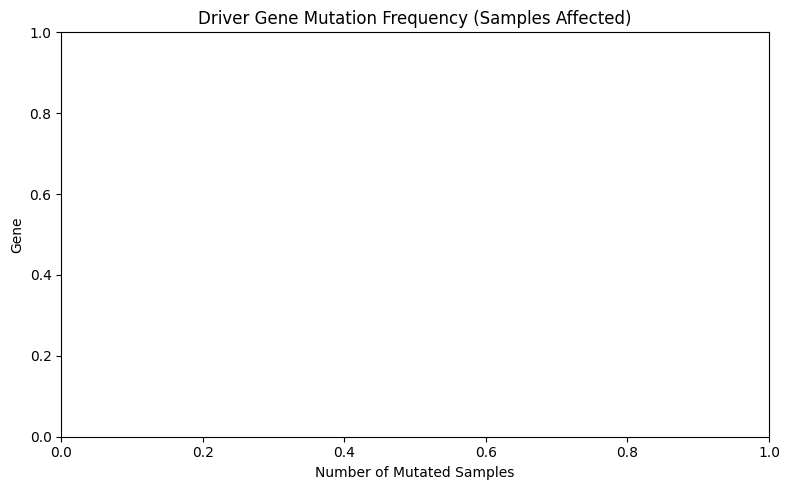

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=mutation_frequency, x="sample_count", y="Hugo_Symbol", palette="viridis")
plt.title("Driver Gene Mutation Frequency (Samples Affected)")
plt.xlabel("Number of Mutated Samples")
plt.ylabel("Gene")
plt.tight_layout()
plt.savefig("oncoplot.png", dpi=200)
plt.show()


## 2.5 Mutation Heatmap (Gene x Sample)

In [ ]:
if not driver_muts.empty:
    pivot = pd.crosstab(driver_muts["Hugo_Symbol"], driver_muts["Tumor_Sample_Barcode"])
    plt.figure(figsize=(12,5))
    sns.heatmap(pivot.iloc[:, :50] if pivot.shape[1] > 50 else pivot, cmap="Reds", cbar_kws={"label":"Mutation count"})
    plt.title("Driver Gene Mutation Heatmap (subset of samples)")
    plt.tight_layout()
    plt.savefig("mutation_heatmap.png", dpi=200)
    plt.show()
else:
    print("No mutation data loaded yet — run Notebook 1 first or place MAF files in data/maf/")


No mutation data loaded yet — run Notebook 1 first or place MAF files in data/maf/


## 2.6 Lollipop Plot Example (single gene)
Change `GENE_OF_INTEREST` to visualize protein-level mutation hotspots.

In [ ]:
GENE_OF_INTEREST = "BRAF"
gene_df = driver_muts[driver_muts["Hugo_Symbol"] == GENE_OF_INTEREST]

if not gene_df.empty and "HGVSp_Short" in gene_df.columns:
    counts = gene_df["HGVSp_Short"].value_counts().head(15)
    plt.figure(figsize=(9,4))
    plt.stem(counts.index, counts.values)
    plt.xticks(rotation=75, ha="right")
    plt.title(f"{GENE_OF_INTEREST} Protein-Level Mutation Hotspots (Lollipop)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(f"{GENE_OF_INTEREST}_lollipop.png", dpi=200)
    plt.show()
else:
    print("Insufficient data for lollipop plot — check HGVSp_Short column availability.")


Insufficient data for lollipop plot — check HGVSp_Short column availability.


Deliverables saved: `driver_mutations.csv`, `oncoplot.png`, `mutation_heatmap.png`.

**Next:** `03_Patient_Stratification.ipynb`